In [1]:
# --- Imports & path setup -------------------------------------------------
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
from IPython.display import Image, display, Markdown

from data_loader import PROJECT_ROOT
from analyze_study import analyze

DATASET = "fashion_mnist"
FRAMEWORK = "botorch"
OTHER_FRAMEWORK = "pymoo"

In [2]:
STUDY_DIR = None    # set to a Path() to override; otherwise auto-discover latest

if STUDY_DIR is None:
    runs = sorted((PROJECT_ROOT / "results" / FRAMEWORK / DATASET).iterdir(), key=lambda p: p.name)
    runs = [r for r in runs if r.is_dir()]
    if not runs:
        raise SystemExit(f"No {FRAMEWORK} runs found under results/{FRAMEWORK}/{DATASET}.")
    STUDY_DIR = runs[-1]

print(f"Study dir: {STUDY_DIR}")
print(f"Files    : {sorted(p.name for p in STUDY_DIR.iterdir())}")

Study dir: D:\forKrishna\MOML\results\botorch\fashion_mnist\botorch_qnehvi_fashion_mnist_20260428_094208
Files    : ['appendix_solution.json', 'pareto_front.csv', 'pareto_metrics.json', 'pareto_table.csv', 'plot_2d_panels.png', 'plot_3d_pareto.png', 'plot_3d_scatter.png', 'plot_parallel_coords.png', 'summary.json', 'trials.csv']


In [3]:
with (STUDY_DIR / "summary.json").open() as f:
    summary = json.load(f)

print(f"Framework      : {summary.get('framework')} — {summary.get('algorithm')}")
print(f"Dataset        : {summary.get('dataset_name')}")
print(f"Device         : {summary.get('device')}")
print(f"Trials         : {summary.get('n_trials_completed')}  (init={summary.get('n_init')}, bo={summary.get('n_bo')})")
print(f"Train subset   : {summary.get('train_subset_size')}")
print(f"Seed           : {summary.get('seed')}")
if summary.get('use_amp') is not None:
    print(f"AMP            : {summary.get('use_amp')}")
print(f"Acqf knobs     : restarts={summary.get('num_restarts')}, raw_samples={summary.get('raw_samples')}, mc_samples={summary.get('mc_samples')}")
print(f"Elapsed        : {summary.get('elapsed_seconds', 0)/60:.1f} min")
print(f"Pareto pts     : {summary.get('n_pareto_points')}  (over all {summary.get('n_trials_completed')} trials)")

Framework      : botorch — qNEHVI
Dataset        : fashion_mnist
Device         : cuda
Trials         : 80  (init=16, bo=64)
Train subset   : 8000
Seed           : 42
Acqf knobs     : restarts=3, raw_samples=64, mc_samples=16
Elapsed        : 102.7 min
Pareto pts     : 21  (over all 80 trials)


In [4]:
# Recompute analysis (rebuilds metrics + plots fresh from trials.csv).
metrics = analyze(STUDY_DIR)

print(f"n_trials       : {metrics['n_trials']}")
print(f"n_pareto       : {metrics['n_pareto_points']}  (recomputed over ALL trials, init + bo)")
print(f"hypervolume    : {metrics['hypervolume']:,.2f}   (higher = better)")
print(f"spacing        : {metrics['spacing']:.4f}   (lower = better, more uniform)")
print()
print("Best objective values seen:")
print(f"  best accuracy     : {metrics['extremes']['accuracy_max']:.4f}")
print(f"  fastest inference : {metrics['extremes']['inference_ms_min']:.4f} ms")
print(f"  smallest model    : {metrics['extremes']['param_count_min']:,} params")

n_trials       : 80
n_pareto       : 21  (recomputed over ALL trials, init + bo)
hypervolume    : 8,731,592,649.51   (higher = better)
spacing        : 0.1700   (lower = better, more uniform)

Best objective values seen:
  best accuracy     : 0.8739
  fastest inference : 0.2168 ms
  smallest model    : 2,538 params


In [5]:
table = pd.read_csv(STUDY_DIR / "pareto_table.csv")
table.set_index("label", inplace=True)
table

,trial_number,accuracy,inference_ms,param_count,arch_type,num_conv_layers,num_channels,num_fc_units,learning_rate,batch_size,num_epochs,dropout_rate,optimizer_type,input_resolution
label,,,,,,,,,,,,,,
fast,17,0.6569,0.2168,2538,plain,1,8,128,0.01,16,10,0.245593,Adam,16
small,17,0.6569,0.2168,2538,plain,1,8,128,0.01,16,10,0.245593,Adam,16
accurate,37,0.8739,1.6195,258762,plain,4,32,128,0.01,64,5,0.262889,SGD,28
balanced,16,0.8527,0.5142,20826,plain,4,8,128,0.01,16,7,0.244369,SGD,16


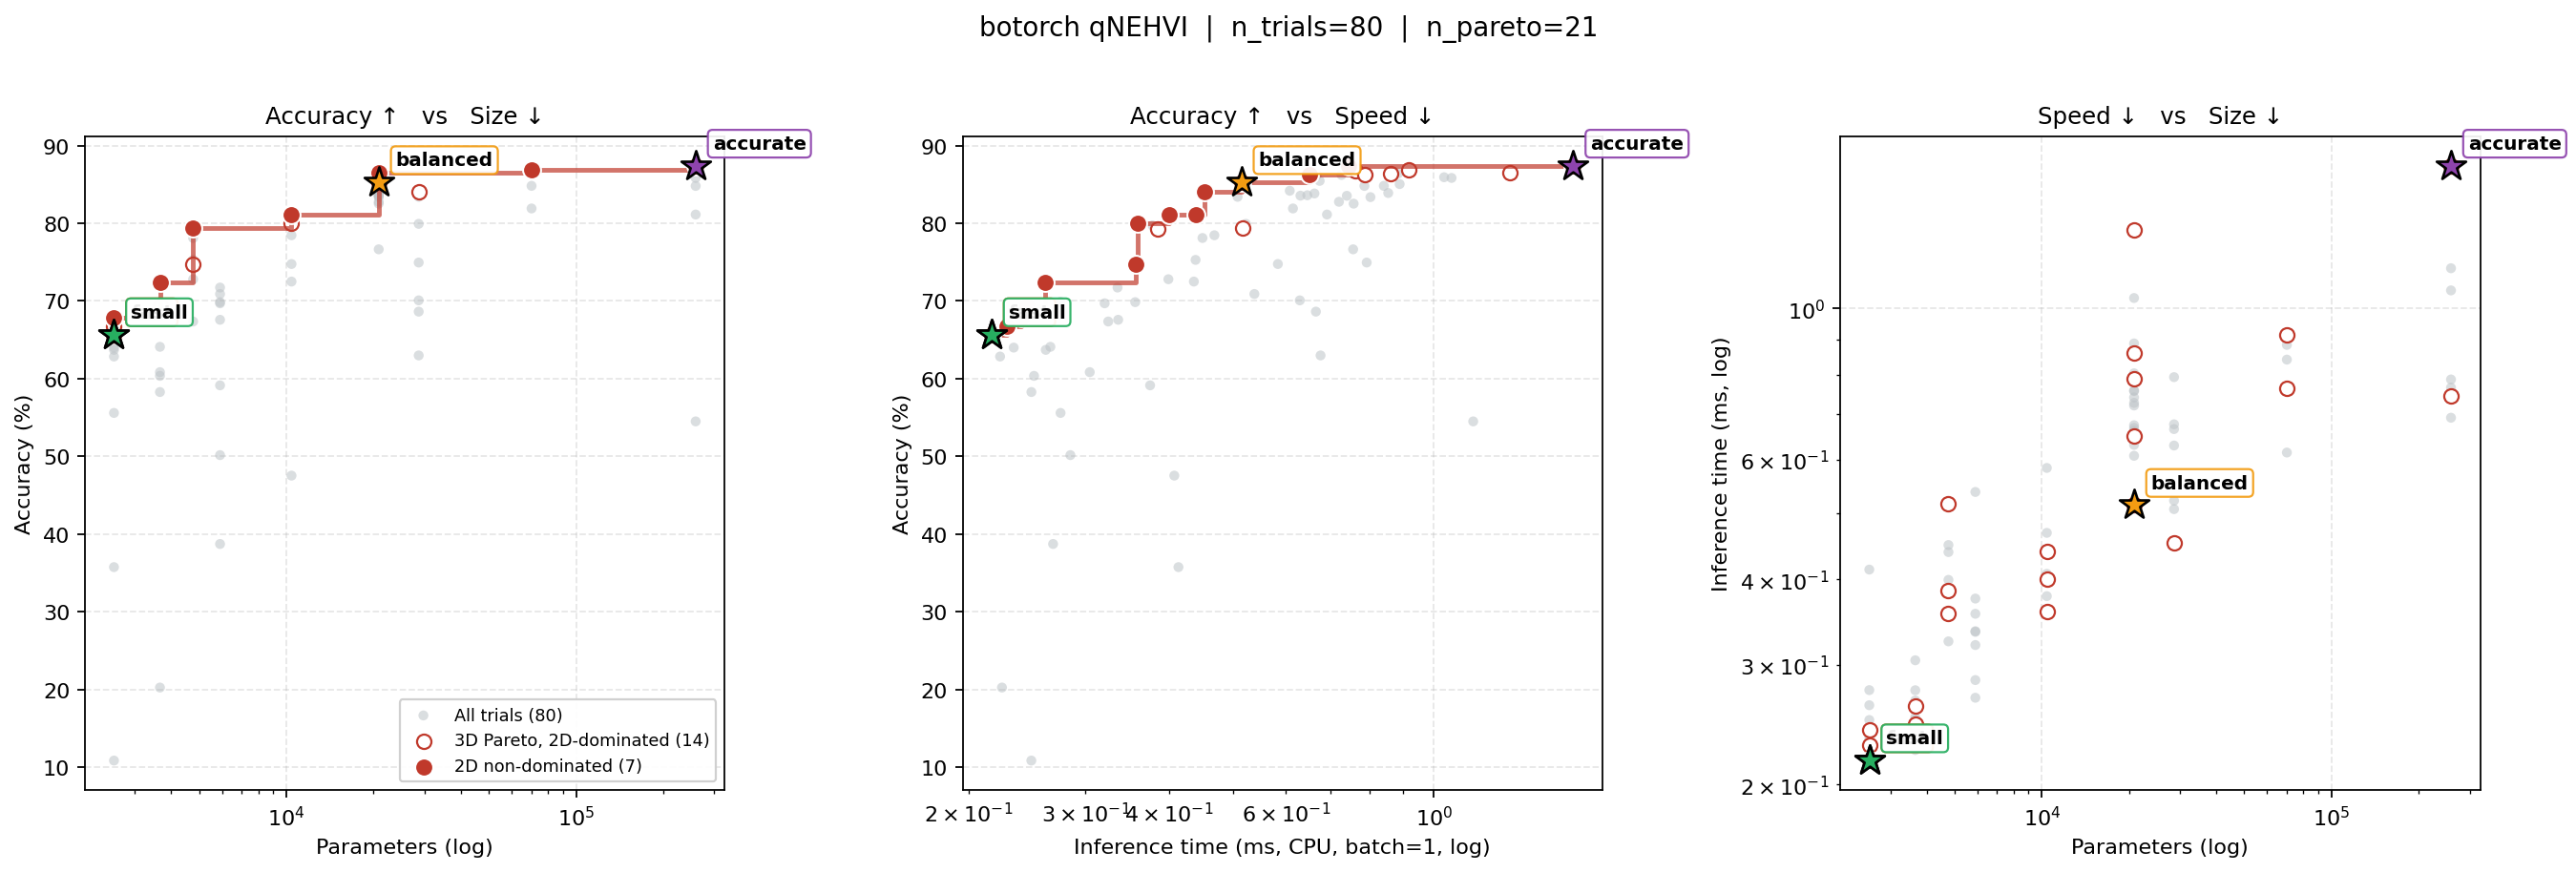

In [6]:
display(Image(filename=str(STUDY_DIR / "plot_2d_panels.png")))

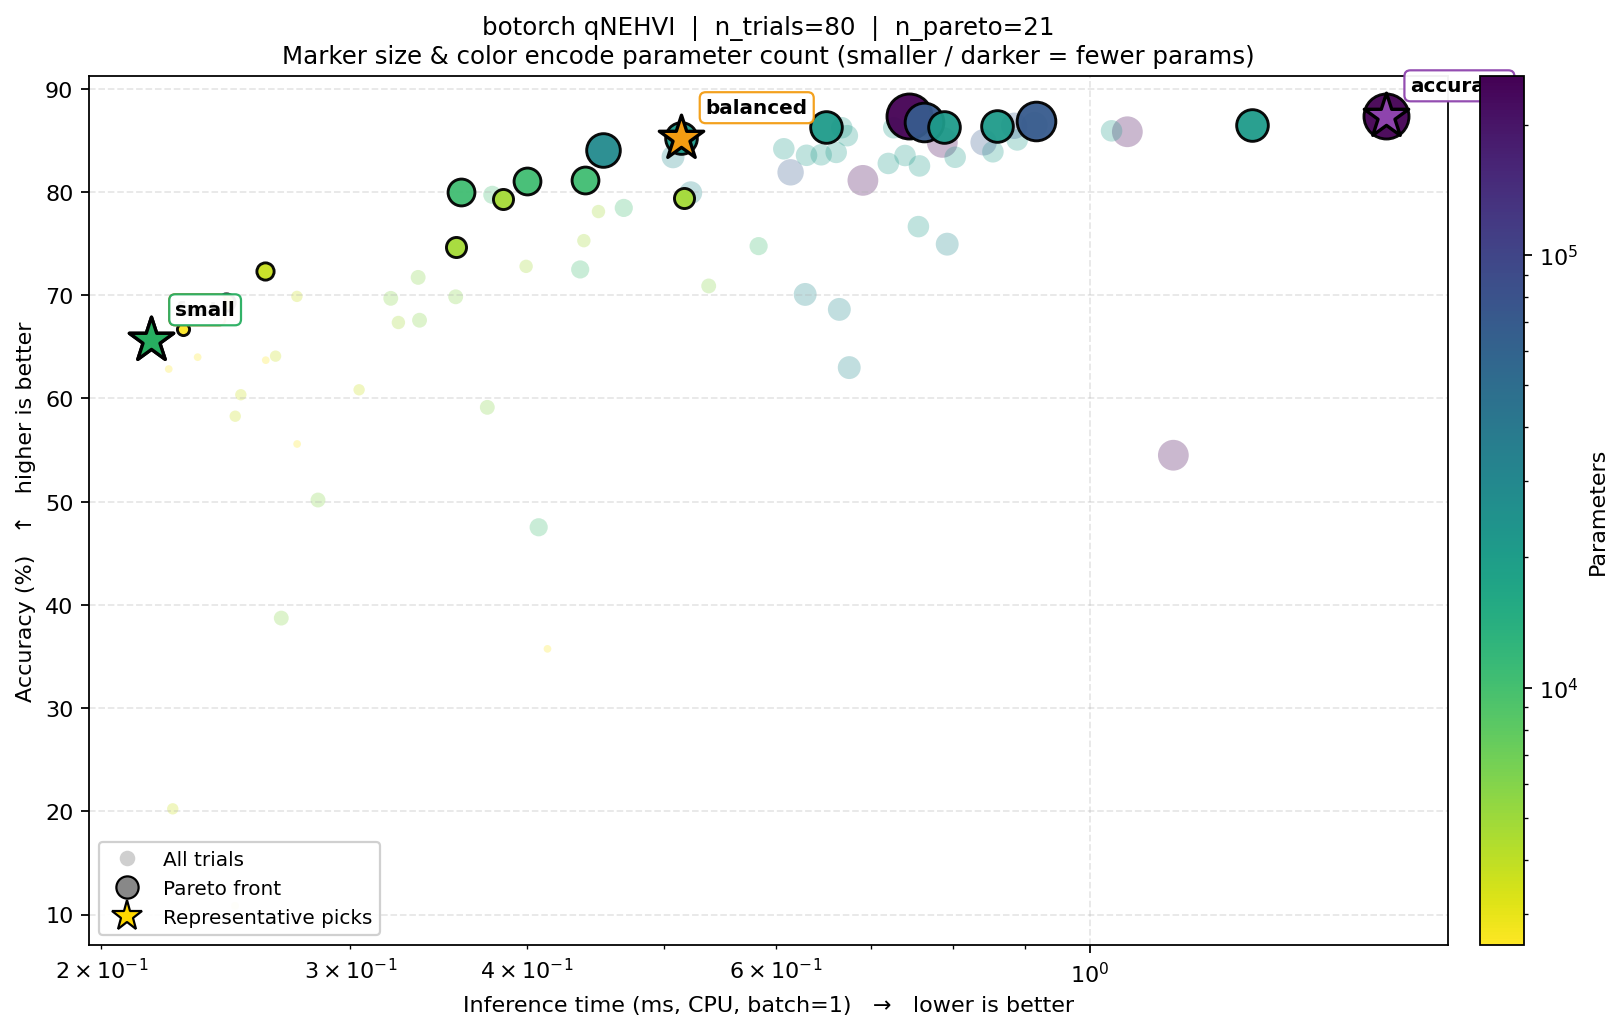

In [8]:
display(Image(filename=str(STUDY_DIR / "plot_3d_scatter.png")))

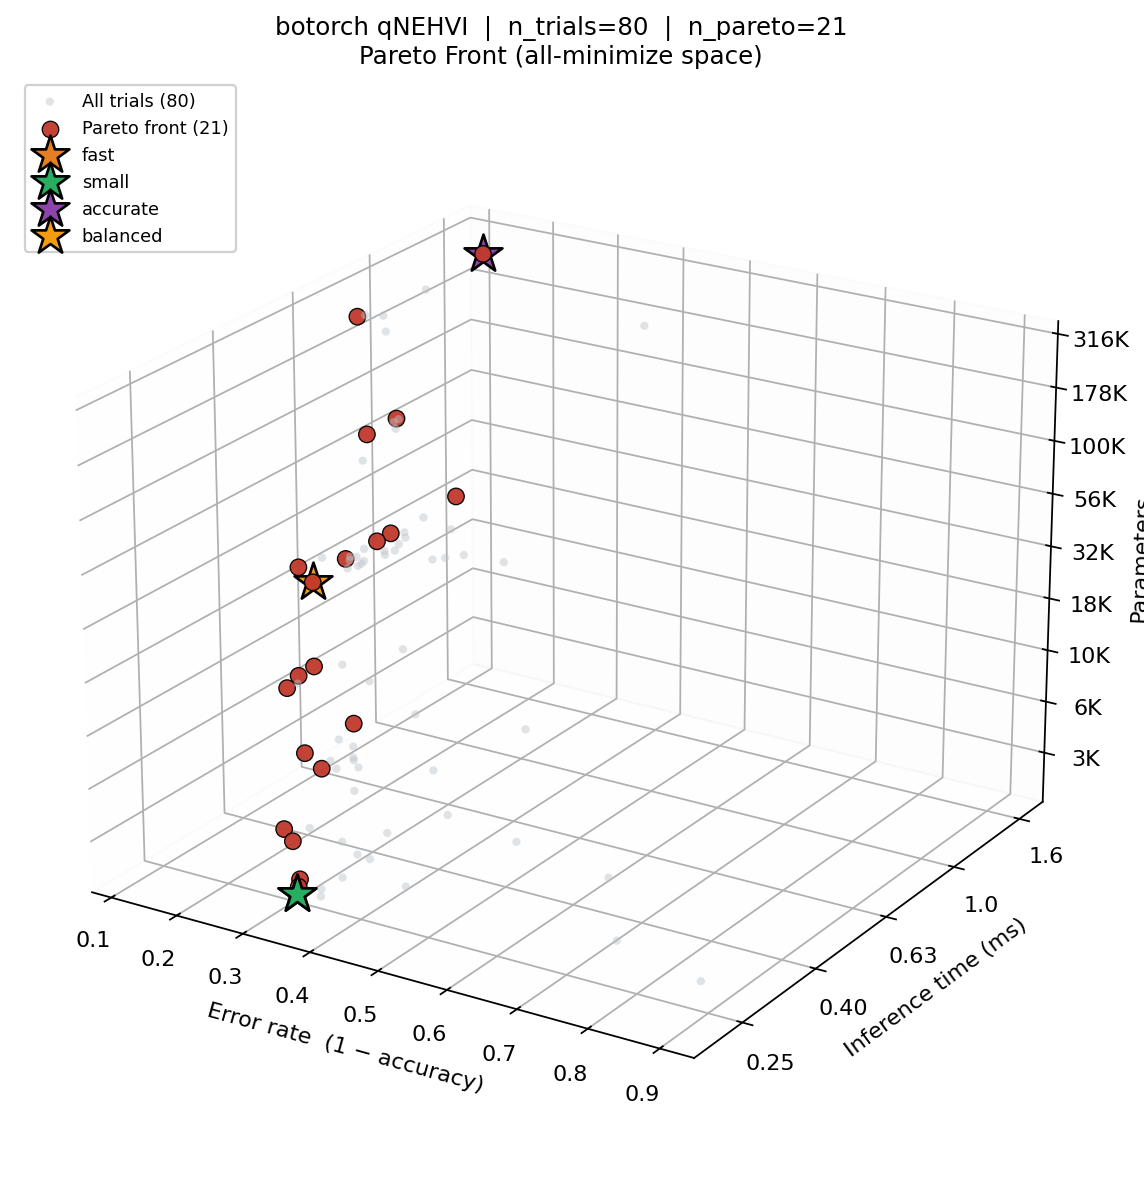

In [9]:
display(Image(filename=str(STUDY_DIR / "plot_3d_pareto.png")))

In [10]:
with (STUDY_DIR / "appendix_solution.json").open() as f:
    appendix = json.load(f)

print(f"Label        : {appendix['label']}")
print(f"Trial number : {appendix.get('trial_number')}")
print()
print("--- Objectives ---")
for k, v in appendix['objectives'].items():
    print(f"  {k:<14s} : {v}")
print()
print("--- Decision variables ---")
for k, v in appendix['decision_variables'].items():
    print(f"  {k:<18s} : {v}")

Label        : balanced (closest-to-ideal Pareto point)
Trial number : 16

--- Objectives ---
  accuracy       : 0.8527
  inference_ms   : 0.514238
  param_count    : 20826

--- Decision variables ---
  arch_type          : plain
  num_conv_layers    : 4
  num_channels       : 8
  num_fc_units       : 128
  learning_rate      : 0.01
  batch_size         : 16
  num_epochs         : 7
  dropout_rate       : 0.24436938426036672
  optimizer_type     : SGD
  input_resolution   : 16


In [11]:
candidate = PROJECT_ROOT / "results" / OTHER_FRAMEWORK / DATASET
compare_path = None
if candidate.exists():
    other_runs = sorted([p for p in candidate.iterdir() if p.is_dir()], key=lambda p: p.name)
    if other_runs:
        compare_path = other_runs[-1] / "pareto_front.csv"

if compare_path is None or not compare_path.exists():
    print(f"No {OTHER_FRAMEWORK} run found under {candidate}.")
    print(f"Run {OTHER_FRAMEWORK}_optimization.ipynb first, then re-run this cell.")
else:
    print(f"Comparing against : {compare_path.parent.name}")
    print()
    metrics_cmp = analyze(STUDY_DIR, compare_pareto_path=compare_path)
    if "comparison" in metrics_cmp:
        c = metrics_cmp["comparison"]
        print("--- joint-front analysis ---")
        print(f"joint pareto      : {c['joint_n_pareto']}")
        print(f"ours surviving    : {c['ours_surviving_in_joint']:>3d} / {metrics_cmp['n_pareto_points']}  ({100*c['ours_surviving_in_joint']/max(1,metrics_cmp['n_pareto_points']):.0f}%)")
        print(f"other surviving   : {c['other_surviving_in_joint']:>3d} / {c['compare_n_pareto']}  ({100*c['other_surviving_in_joint']/max(1,c['compare_n_pareto']):.0f}%)")
        print(f"GD ours -> joint  : {c['gd_ours_to_joint']:.6f}  (lower = better)")
        print(f"GD other-> joint  : {c['gd_other_to_joint']:.6f}")
        print()
        winner = "botorch" if c['gd_ours_to_joint'] < c['gd_other_to_joint'] else OTHER_FRAMEWORK
        print(f"Closer to joint front (lower GD): {winner}")
    print()
    print("Plots have been refreshed with the comparison overlay. Re-display them with the cells above to see the head-to-head visually.")

Comparing against : pymoo_nsga2_fashion_mnist_20260427_231035

--- joint-front analysis ---
joint pareto      : 25
ours surviving    :  19 / 21  (90%)
other surviving   :   6 / 18  (33%)
GD ours -> joint  : 0.066921  (lower = better)
GD other-> joint  : 0.066685

Closer to joint front (lower GD): pymoo

Plots have been refreshed with the comparison overlay. Re-display them with the cells above to see the head-to-head visually.


**2D panels with both fronts (red = ours, blue diamonds = comparison)**

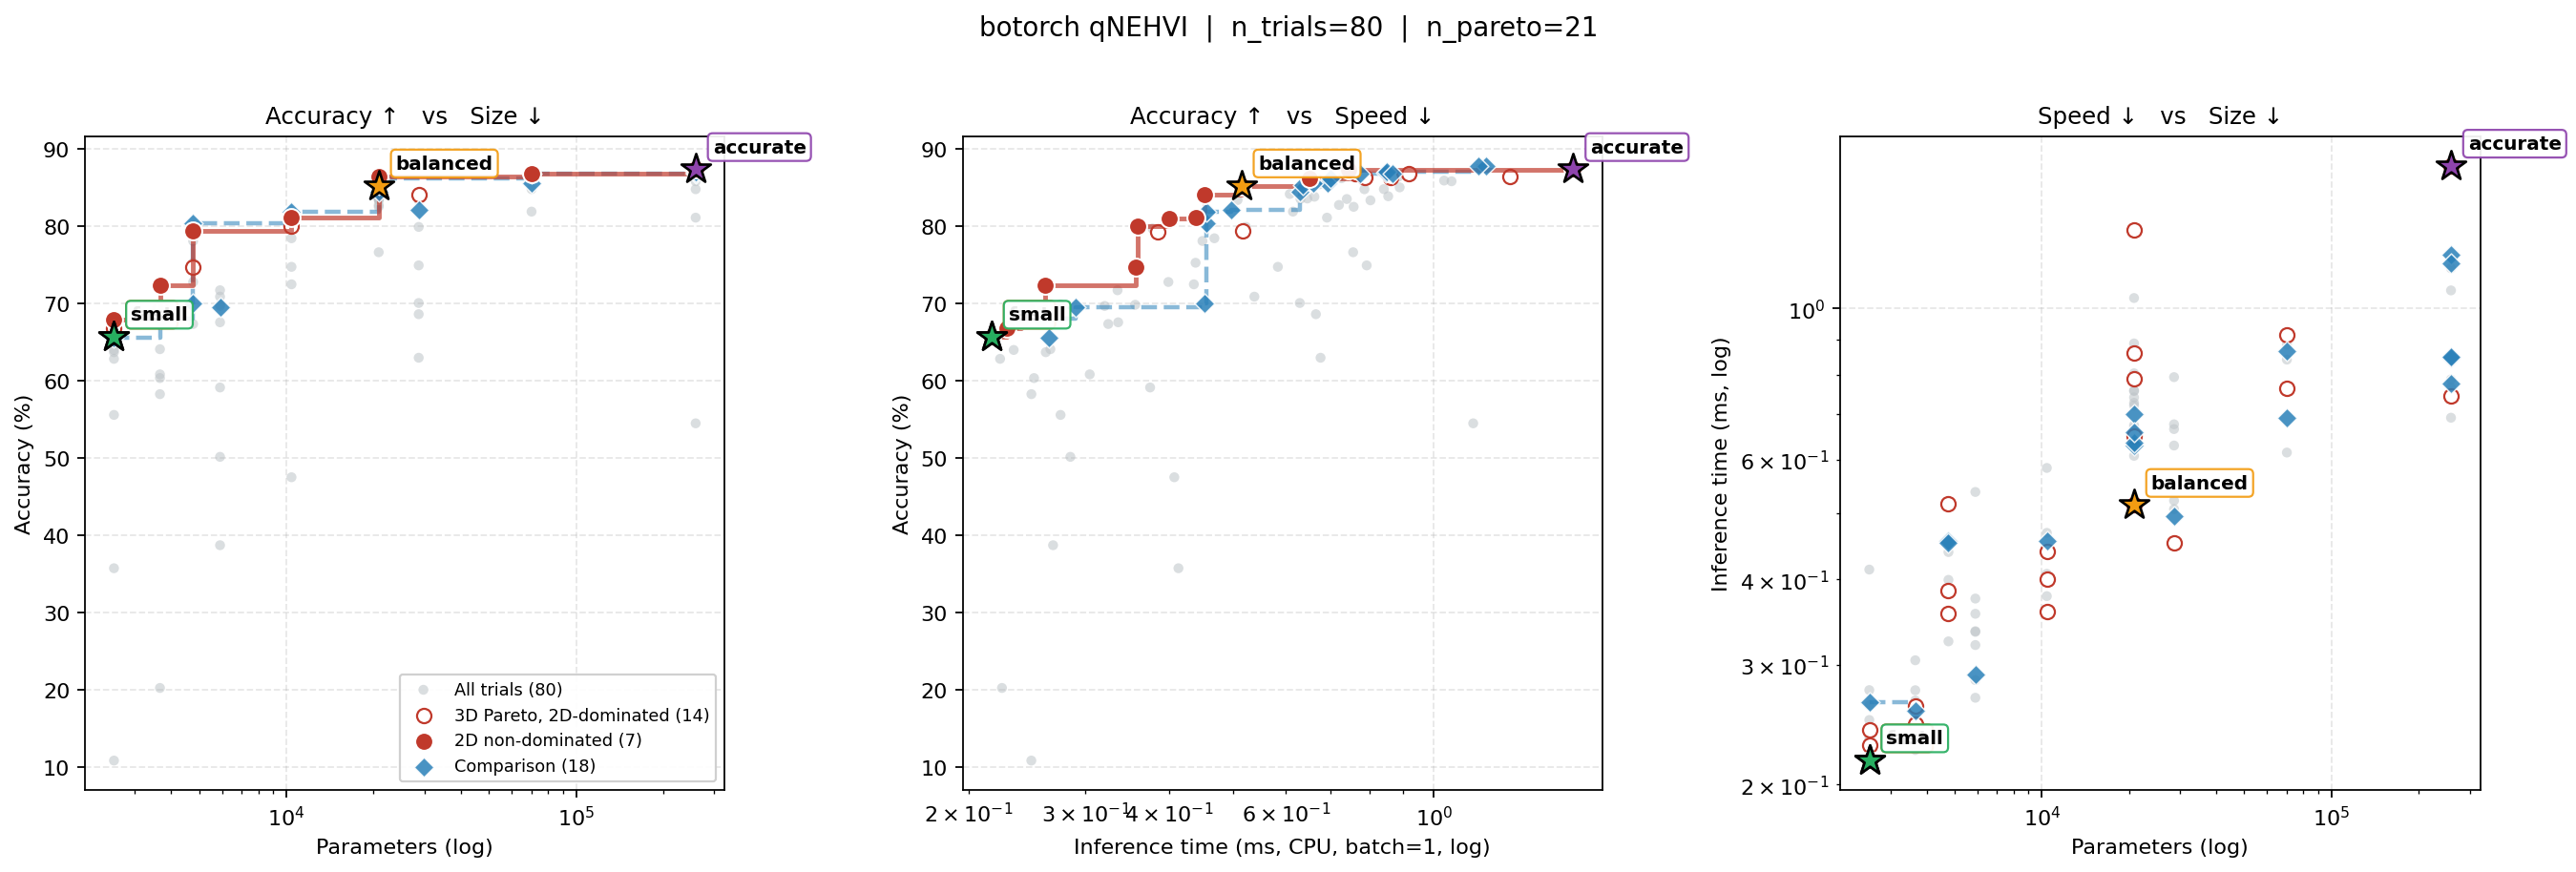

**2D bubble with comparison Pareto (magenta-edged diamonds)**

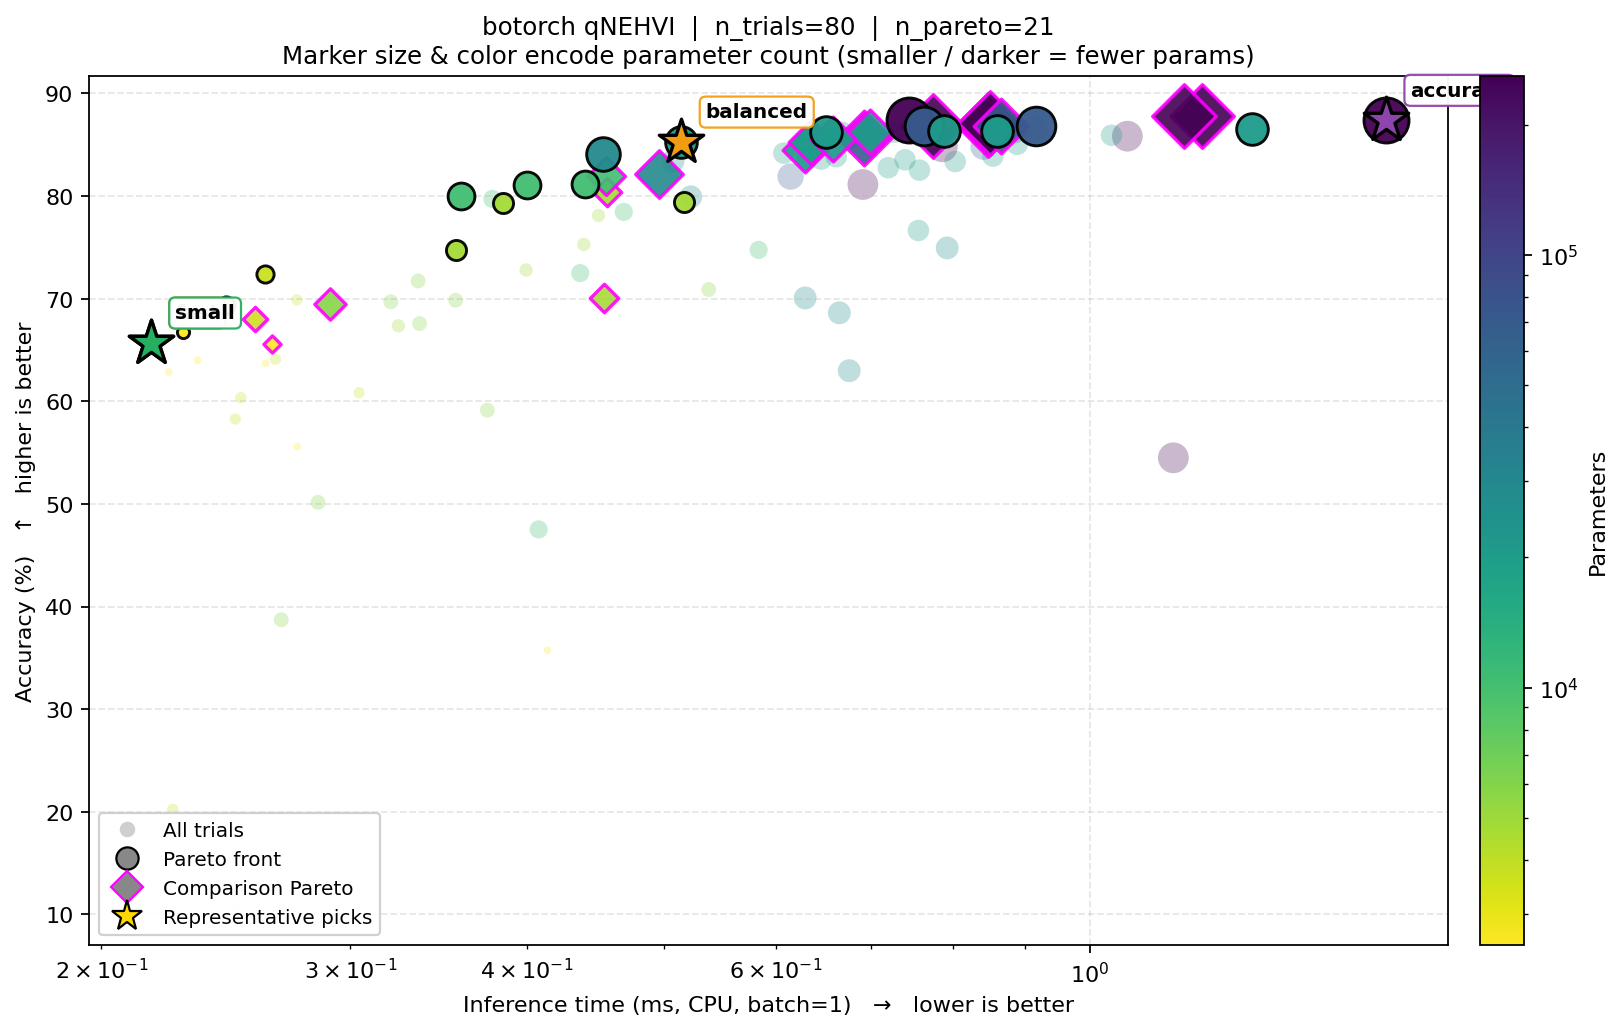

**3D Pareto with comparison overlay (blue diamonds)**

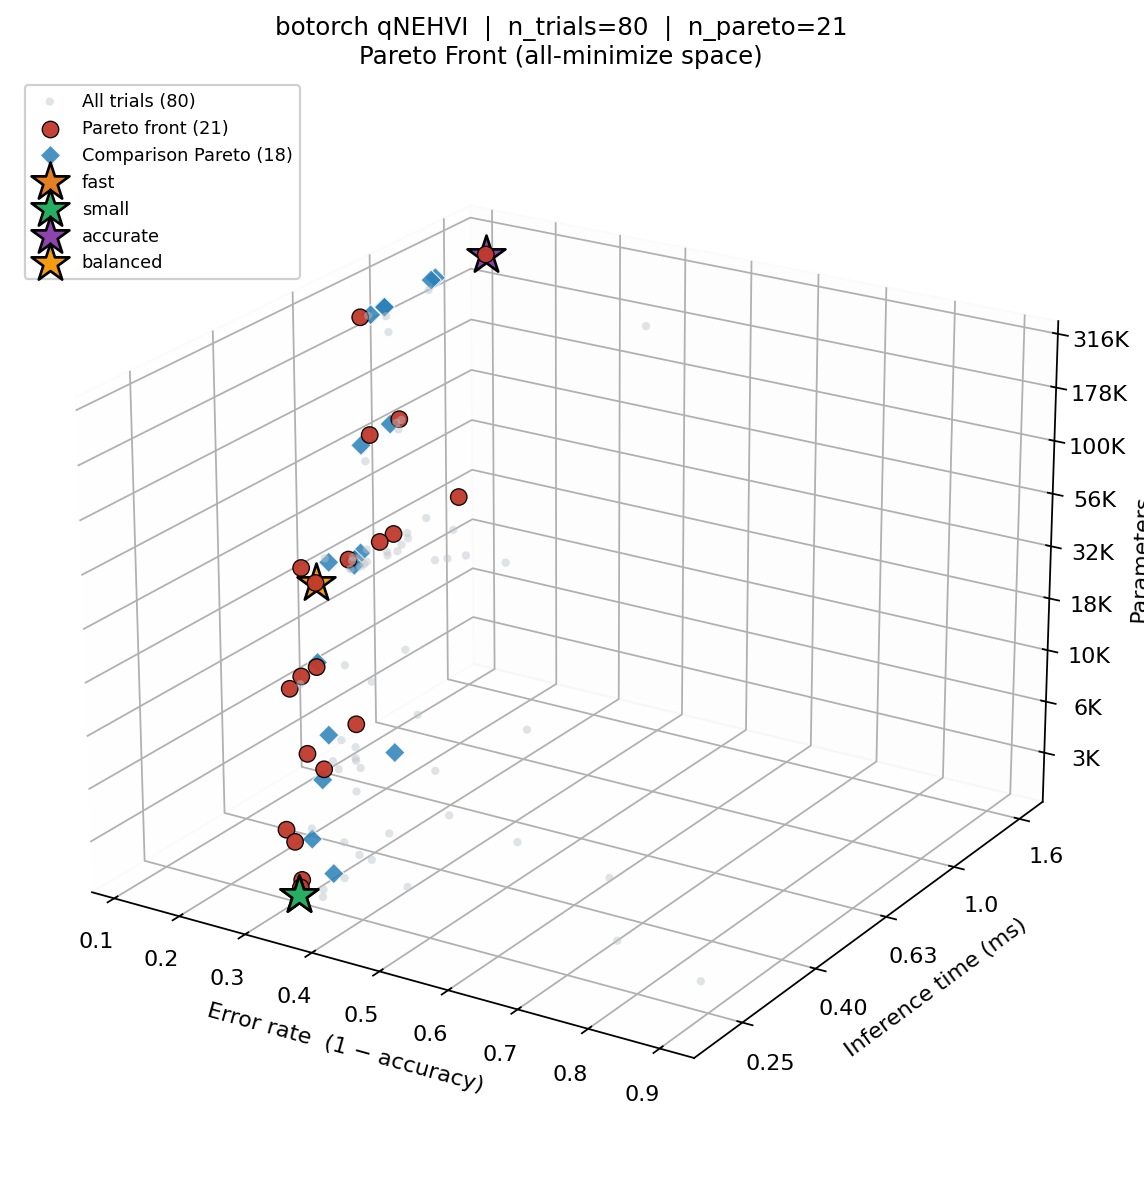

In [12]:
for fname, caption in [
    ("plot_2d_panels.png",       "2D panels with both fronts (red = ours, blue diamonds = comparison)"),
    ("plot_3d_scatter.png",      "2D bubble with comparison Pareto (magenta-edged diamonds)"),
    ("plot_3d_pareto.png",       "3D Pareto with comparison overlay (blue diamonds)"),
]:
    display(Markdown(f"**{caption}**"))
    display(Image(filename=str(STUDY_DIR / fname)))